# Stage 6e Part A: baseline emulator training convergence (K=400)

Plots the baseline emulator's own per-step training loss (`train_baseline_emulator`'s
existing `losses` return value) at the pipeline's current, fixed training length
K=400 (locked at 400 rather than independently tuned, so the baseline and the
optimized emulator remain an apples-to-apples comparison in training budget -
K_inner is likewise fixed at 400 throughout the optimized-emulator side). Shows the
mean loss curve across seeds with a 95% confidence interval band, to check whether
training has plateaued by step 400 or is still descending steeply.

Data source: `data/SI_results/baseline_hp/convergence_curves_K400.npy`, produced by
`scripts/6e_baseline_convergence.py` (5 seeds, lr=0.05, weight_decay=0.01 - the
current baseline hyperparameters).

In [1]:
import os, sys
PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from cmcrameri import cm

%load_ext autoreload
%autoreload 2

OUT_DIR = os.path.join(PROJECT_ROOT, "data", "SI_results", "baseline_hp")

In [2]:
curves = np.load(os.path.join(OUT_DIR, "convergence_curves_K400.npy"))  # (n_seeds, K)
n_seeds, K = curves.shape
print(f"curves shape: {curves.shape} (n_seeds={n_seeds}, K={K})")

steps = np.arange(K)
mean_curve = curves.mean(axis=0)
sem_curve = curves.std(axis=0, ddof=1) / np.sqrt(n_seeds)

ci_mult = stats.t.ppf(0.975, df=n_seeds - 1)  # 95% CI, small-n (n=5) -> use t, not normal
ci_lo = mean_curve - ci_mult * sem_curve
ci_hi = mean_curve + ci_mult * sem_curve
ci_lo = np.clip(ci_lo, a_min=1e-12, a_max=None)  # keep positive for log axis

for i in range(n_seeds):
    print(f"seed={i}: loss0={curves[i, 0]:.4g} lossF={curves[i, -1]:.4g} "
          f"min={curves[i].min():.4g} at step {curves[i].argmin()}")

curves shape: (5, 400) (n_seeds=5, K=400)
seed=0: loss0=13.94 lossF=0.008319 min=0.008319 at step 399
seed=1: loss0=18.5 lossF=0.009513 min=0.009513 at step 399
seed=2: loss0=15.01 lossF=0.009039 min=0.009039 at step 399
seed=3: loss0=14.77 lossF=0.008665 min=0.008665 at step 399
seed=4: loss0=16.03 lossF=0.008901 min=0.008901 at step 399


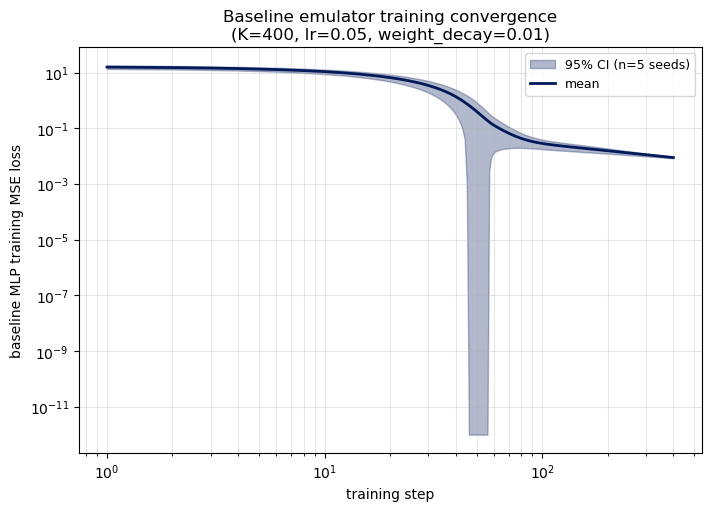

In [3]:
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax.fill_between(steps + 1, ci_lo, ci_hi, color=cm.batlowS(0), alpha=0.3,
                label="95% CI (n=5 seeds)")
ax.loglog(steps + 1, mean_curve, color=cm.batlowS(0), lw=2, label="mean")
ax.set_xlabel("training step")
ax.set_ylabel("baseline MLP training MSE loss")
ax.set_title("Baseline emulator training convergence\n(K=400, lr=0.05, weight_decay=0.01)")
ax.grid(True, alpha=0.3, which="both")
ax.legend(fontsize=9)
fig.savefig(os.path.join(OUT_DIR, "convergence_K400_ci.png"), dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# Plateau diagnostic: loss improvement in the last 10% of training vs. the first 10%.
# A small fraction means training has plateaued by K=400 (not simply cut short).
tail_frac = int(0.1 * K)
early_drop = mean_curve[0] - mean_curve[tail_frac]
late_drop = mean_curve[-tail_frac - 1] - mean_curve[-1]
print(f"Plateau check: loss drop in first 10% of training = {early_drop:.4g}, "
      f"drop in last 10% = {late_drop:.4g} "
      f"({100 * late_drop / max(early_drop, 1e-12):.2f}% of the early rate)")

Plateau check: loss drop in first 10% of training = 14.43, drop in last 10% = 0.0007012 (0.00% of the early rate)
